# Laporan Jobsheet Pertemuan 07

**Modul 6 – Filter Spasial: Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection**

**Nama  : Mochammad Rijal Dzaki Rifki Afifudin**

**NIM   : 244107020240**

**Kelas : TI-3C**

## D. PRAKTIKUM FILTER

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

base_path = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/'

### Konvolusi tanpa Library — Membuat fungsi konvolusi

Fungsi konvolusi yang dibuat memiliki parameter berupa:
1. citra masukan,
2. kernel berupa matriks untuk memfilter citra,
3. nilai stride / besarnya pergeseran untuk setiap konvolusi,
4. nilai pad yang akan ditambahkan pada citra.

In [4]:
def convolution2d(image, kernel, stride, padding):
    image = np.pad(image, padding, mode='constant', constant_values=0)

    kernel_height, kernel_width = kernel.shape
    padded_height, padded_width = image.shape

    # Ukuran citra keluaran
    output_height = (padded_height - kernel_height) // stride + 1
    output_width = (padded_width - kernel_width) // stride + 1

    new_image = np.zeros((output_height, output_width)).astype(np.float32)

    # Proses konvolusi: kernel digeser sebesar stride di seluruh citra
    for y in range(0, output_height):
        for x in range(0, output_width):
            new_image[y][x] = np.sum(
                image[y * stride : y * stride + kernel_height,
                      x * stride : x * stride + kernel_width] * kernel
            ).astype(np.float32)

    return new_image

### Load citra yang akan diproses dan ubah menjadi citra keabuan

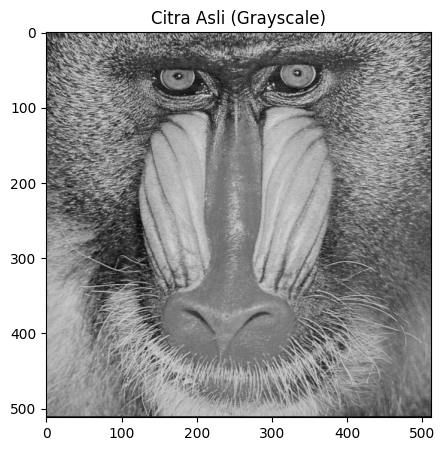

In [5]:
img = cv.imread(base_path + 'mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Asli (Grayscale)')
plt.show()

### Menentukan kernel yang akan digunakan (contoh: kernel filter sharpening)

In [6]:
# Image sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

### Memanggil fungsi konvolusi yang telah dibuat sebelumnya dan menampilkan hasil konvolusinya

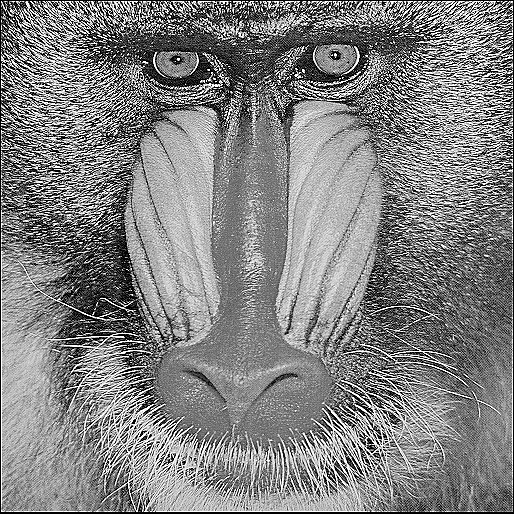

In [7]:
cv2_imshow(convolution2d(img_gray, kernel_sharpen, 1, 2))

### 3. Buat Image Filter untuk Average Filter, Low Pass Filter, High Pass Filter, dan beberapa filter berikut:

| Operasi | Kernel |
|---|---|
| Sharpen | $\begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$ |
| Emboss | $\begin{bmatrix} -2 & -1 & 0 \\ -1 & 1 & 1 \\ 0 & 1 & 2 \end{bmatrix}$ |
| Left Sobel Edge Detection | $\begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix}$ |
| Canny Edge Detection | $\begin{bmatrix} -1 & -1 & -1 \\ -1 & 8 & -1 \\ -1 & -1 & -1 \end{bmatrix}$ |
| Average Filter 3x3 | $\frac{1}{9}\begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}$ |
| Low Pass Filter | $\frac{1}{12}\begin{bmatrix} 1 & 1 & 1 \\ 1 & 4 & 1 \\ 1 & 1 & 1 \end{bmatrix}$ |
| High Pass Filter | $\begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 3 \\ -3 & 0 & 1 \end{bmatrix}$ |
| 21x21 Gaussian Blur | dibangun dengan `cv.getGaussianKernel` (`sigma = math.sqrt(kernel_size)`, lalu `gaussian_kernel @ gaussian_kernel.transpose()`) |

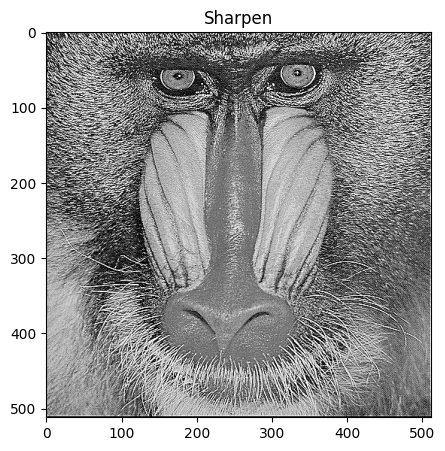

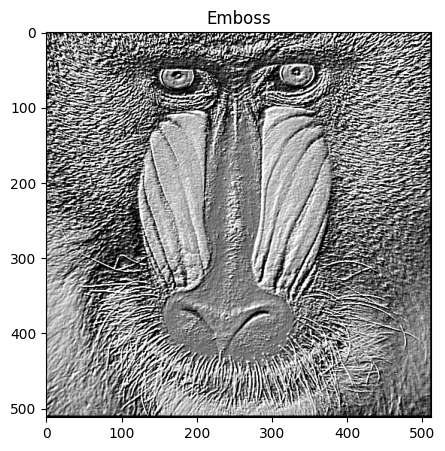

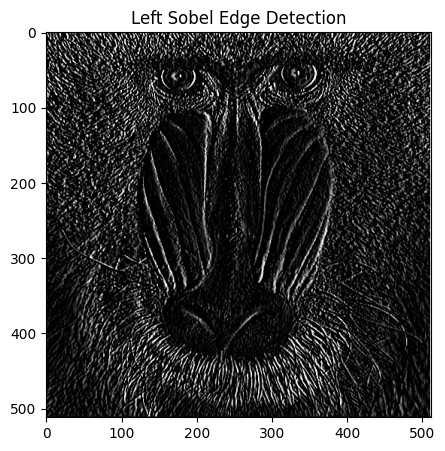

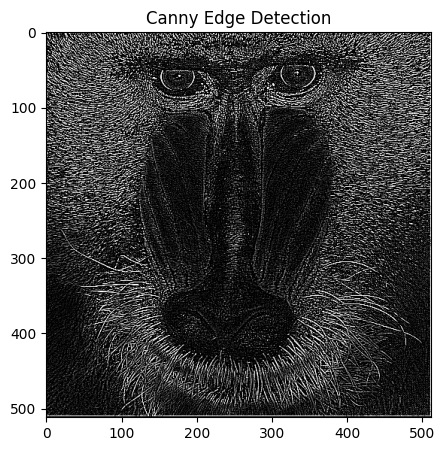

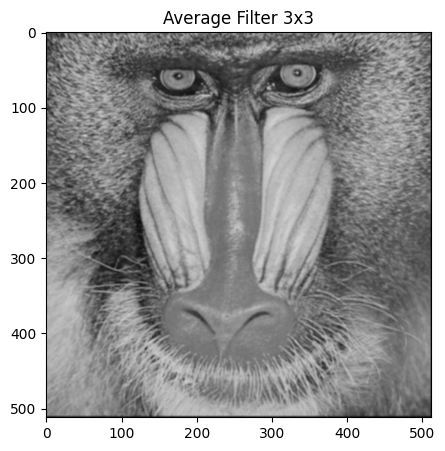

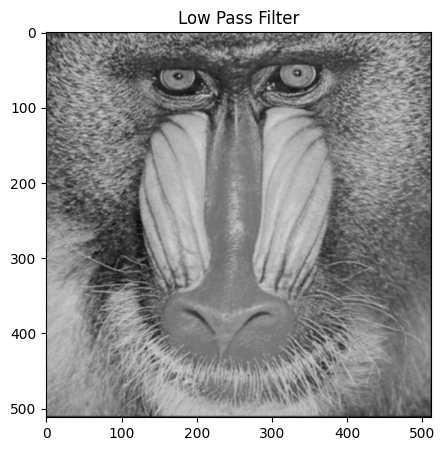

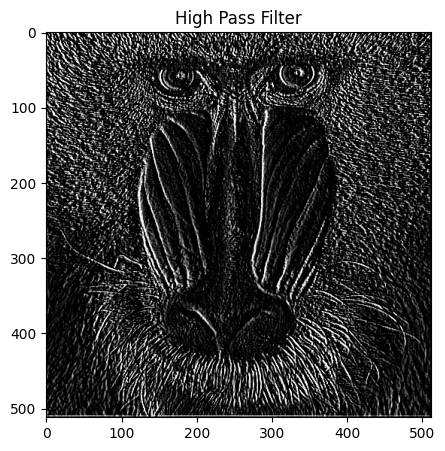

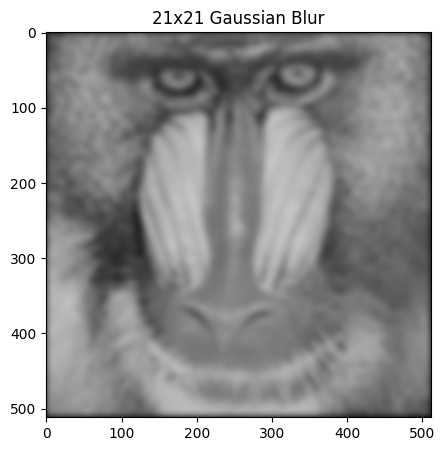

In [8]:
# Menentukan seluruh kernel yang akan digunakan
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]])

kernel_left_sobel = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

kernel_canny = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]])

kernel_average = np.array([[1, 1, 1],
                           [1, 1, 1],
                           [1, 1, 1]]) / 9.0

kernel_lowpass = np.array([[1, 1, 1],
                           [1, 4, 1],
                           [1, 1, 1]]) / 12.0

kernel_highpass = np.array([[-1, 0, 1],
                            [-1, 0, 3],
                            [-3, 0, 1]])

# Kernel Gaussian 21x21
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# Memanggil fungsi konvolusi untuk setiap kernel, lalu menampilkan hasilnya
daftar_filter = {
    'Sharpen':                   (kernel_sharpen,    1),
    'Emboss':                    (kernel_emboss,     1),
    'Left Sobel Edge Detection': (kernel_left_sobel, 1),
    'Canny Edge Detection':      (kernel_canny,      1),
    'Average Filter 3x3':        (kernel_average,    1),
    'Low Pass Filter':           (kernel_lowpass,    1),
    'High Pass Filter':          (kernel_highpass,   1),
    '21x21 Gaussian Blur':       (gauss_kernel,      10),
}

for nama_filter, (kernel, padding) in daftar_filter.items():
    hasil = convolution2d(img_gray, kernel, 1, padding)
    plt.figure(figsize=(5, 5))
    plt.imshow(hasil, cmap='gray', vmin=0, vmax=255)
    plt.title(nama_filter)
    plt.show()

## E. FILTER LIBRARY DAN FILTER MODERN



### Percobaan 1: Filter Gaussian, Sharpen, dan Canny menggunakan library filter2D

Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library `filter2d` dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat fungsi `show_side_by_side` yang digunakan untuk menampilkan gambar secara berdampingan.

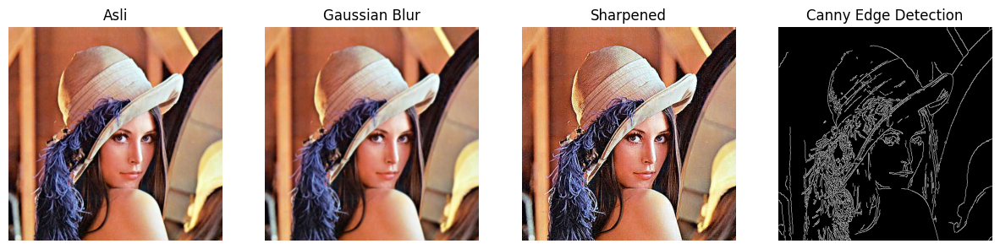

In [9]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread(base_path + 'lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

### Percobaan 2: Bilateral Filtering dan Guided Filter

Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan digunakan adalah **Bilateral Filtering** dan **Guided Filter** (di OpenCV tersedia sebagai *edge preserving filter*).

**Bilateral filtering** adalah sebuah metode penyaringan non-linear yang banyak digunakan untuk menghaluskan citra sekaligus tetap mempertahankan ketajaman tepi. Berbeda dengan Gaussian blur biasa yang hanya memperhitungkan jarak spasial antar piksel, bilateral filter juga mempertimbangkan perbedaan intensitas warna. Dengan cara ini, citra menjadi lebih halus pada area datar, namun garis batas dan detail penting tetap terjaga. Filter ini banyak dipakai untuk perbaikan kualitas foto, pengurangan noise, maupun sebagai dasar efek *beauty filter*.

**Guided filtering** merupakan teknik yang lebih modern dan efisien. Filter ini didasarkan pada asumsi bahwa dalam sebuah jendela lokal, hasil penyaringan dapat direpresentasikan sebagai fungsi linear dari citra pemandu (*guide image*). Guided filter menawarkan keseimbangan antara preservasi tepi yang baik, kualitas visual yang halus, dan efisiensi komputasi, sehingga dianggap sebagai penyempurnaan dari pendekatan bilateral filtering.

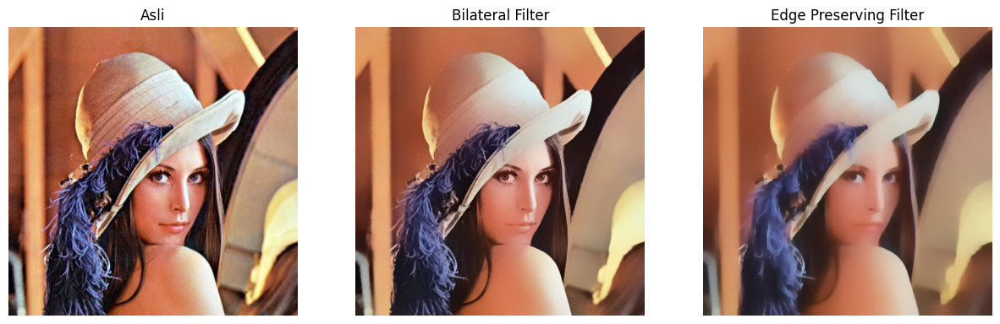

In [10]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

### Percobaan 3: Filtering pada CNN (Feature Map)

Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map). Lakukan running code beberapa kali dan perhatikan hasil outputnya.

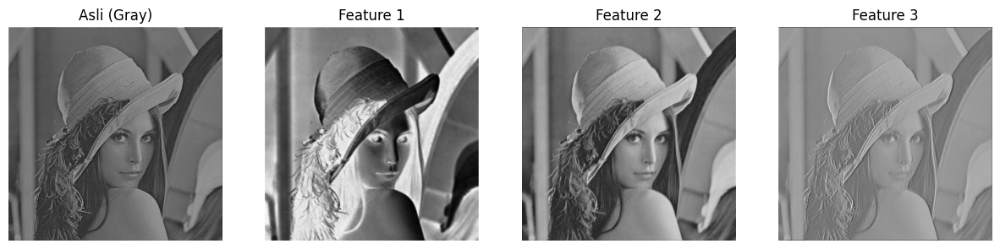

In [11]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side(feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

**Kesimpulan Percobaan 3:**

Setiap kali kode dijalankan (run berulang), hasil feature map selalu berubah. Hal ini terjadi karena bobot (kernel) pada `nn.Conv2d` diinisialisasi secara **acak** setiap kali model dibuat, sehingga 4 kernel 3x3 yang digunakan untuk mengonvolusi citra berbeda pada setiap run.

Feature map tersebut merupakan hasil konvolusi citra grayscale dengan keempat kernel acak tadi, dan polanya mirip filter tradisional (deteksi tepi, tekstur, penajaman) dengan arah/karakter yang berbeda-beda. Kesimpulannya: pada CNN, filter tidak ditentukan manual oleh manusia melainkan **dipelajari secara otomatis melalui proses training**, dan satu lapisan konvolusi menghasilkan banyak feature map (satu per kernel) yang menangkap karakteristik berbeda dari citra yang sama.

### Percobaan 4: Efek Beauty dan Vintage

Percobaan kali ini akan melakukan efek **Beauty** dan **Vintage/Old** yang biasanya digunakan pada aplikasi populer saat ini. Filter yang digunakan merupakan **kombinasi dari filter tradisional** (bilateral filter, unsharp masking, brightness & contrast, sepia tone, vignette, dan noise/grain). Perlu diketahui filter pada aplikasi populer bisa jadi tidak menggunakan metode yang sama, karena bisa saja menggunakan model GenAI dengan data training untuk memberikan hasil yang lebih akurat.

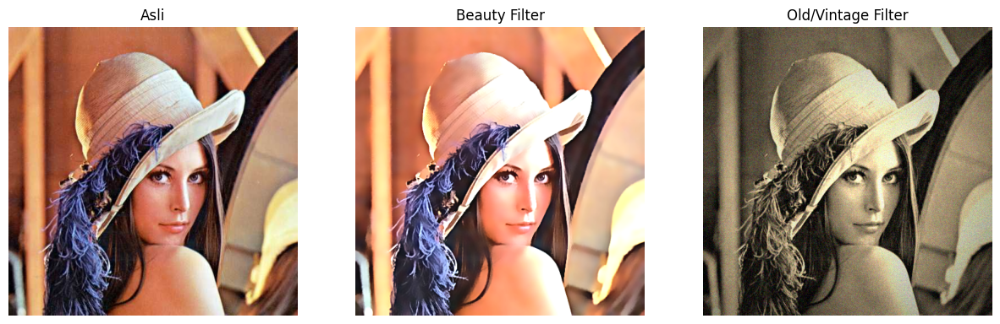

In [12]:
# Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

### Percobaan 5: Filter Anime / Cartoon

Percobaan 5 akan menunjukkan filter anime / cartoon menggunakan kombinasi filter tradisional: *median blur* + *adaptive threshold* untuk garis tepi, *bilateral filter* untuk menghaluskan warna, lalu keduanya digabungkan dengan operasi `bitwise_and`.

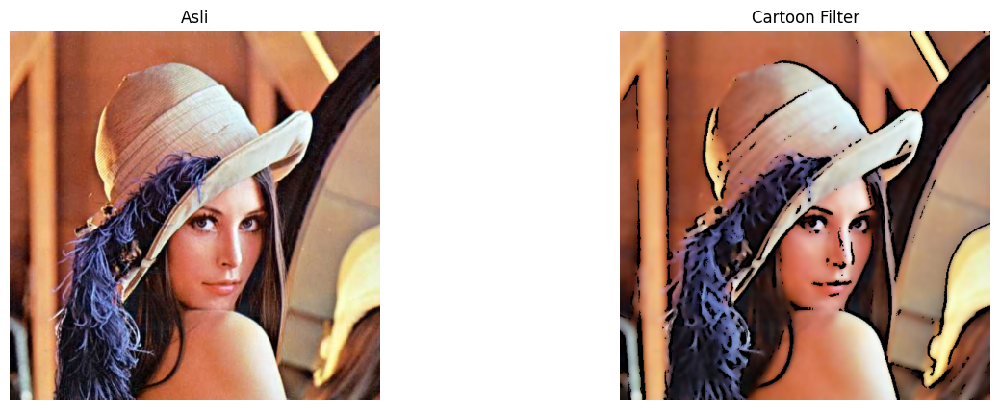

In [13]:
# Filter Anime / Cartoon
# Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

### Percobaan 6: Filter Malam

Pada Percobaan 6 akan ditunjukkan contoh Filter Malam (*Night Filter*): gelapkan citra, tambahkan bias biru, lalu tambahkan efek *glow* pada area terang menggunakan `filter2D` dengan blur kernel.

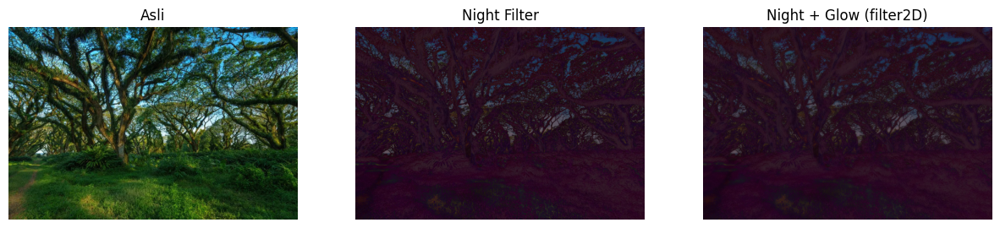

In [14]:
# Night Filter
img = cv.imread(base_path + 'djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasi asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])

### Percobaan 7: Filter Pagi dan Pagi ditambahkan efek kabut

Percobaan 7 menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut: kurangi kontras & cerahkan, tambahkan *warm tone*, lalu tambahkan *haze* (kabut tipis) dengan `filter2D` dan layer putih.

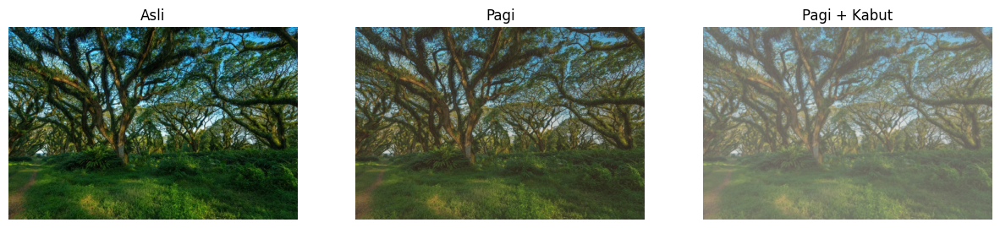

In [15]:
# Filter Suasana pagi dan Kabut
# ============================
# Step 1: Kurangi kontras & cerahkan
# ============================
alpha = 0.9    # contrast
beta = 20      # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

## TUGAS PRAKTIKUM

### 1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise "Salt and Pepper"

a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).
b. Terapkan Mean Filter (3 x 3) dan Median Filter (3 x 3).
c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.

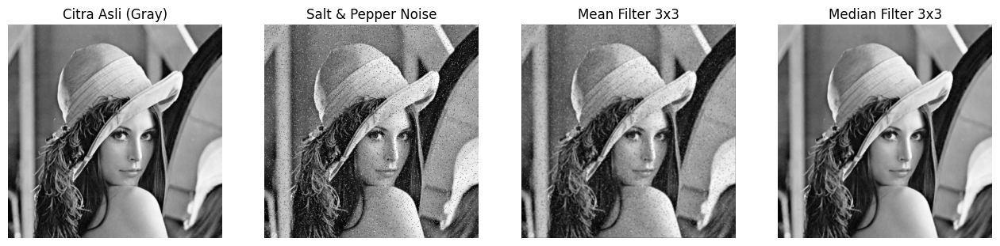

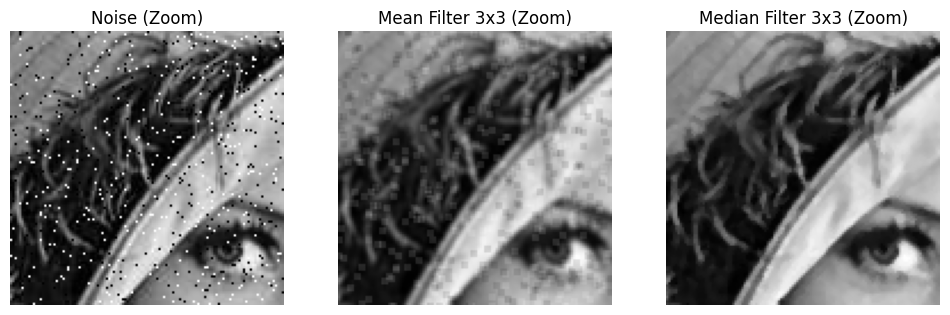

In [16]:
# a. Tambahkan noise Salt and Pepper ke citra keabuan
img_t1 = cv.imread(base_path + 'lena.jpg')
gray_t1 = cv.cvtColor(img_t1, cv.COLOR_BGR2GRAY)

np.random.seed(42)

def salt_pepper_noise(image, amount=0.05):
    """Menambahkan noise salt (255) dan pepper (0) sebanyak `amount` x total piksel."""
    noisy = image.copy()
    num_noise = int(amount * image.size)
    ys = np.random.randint(0, image.shape[0], num_noise)
    xs = np.random.randint(0, image.shape[1], num_noise)
    n_half = num_noise // 2
    noisy[ys[:n_half], xs[:n_half]] = 255   # salt (bintik putih)
    noisy[ys[n_half:], xs[n_half:]] = 0     # pepper (bintik hitam)
    return noisy

noisy_t1 = salt_pepper_noise(gray_t1, amount=0.05)

# b. Terapkan Mean Filter 3x3 (memakai fungsi konvolusi buatan sendiri) dan Median Filter 3x3
kernel_mean_3x3 = np.ones((3, 3), np.float32) / 9.0
mean_filtered = convolution2d(noisy_t1, kernel_mean_3x3, 1, 1)
median_filtered = cv.medianBlur(noisy_t1, 3)   # median filter bersifat non-linear (bukan konvolusi)

# Tampilkan perbandingan
show_side_by_side([gray_t1, noisy_t1, mean_filtered, median_filtered],
                  ["Citra Asli (Gray)", "Salt & Pepper Noise",
                   "Mean Filter 3x3", "Median Filter 3x3"], figsize=(16, 4))

# Potongan citra (zoom) agar perbedaan hasil terlihat lebih jelas
h, w = noisy_t1.shape
ys, ye, xs, xe = h // 3, h // 3 + 120, w // 3, w // 3 + 120
show_side_by_side([noisy_t1[ys:ye, xs:xe],
                   mean_filtered[ys:ye, xs:xe],
                   median_filtered[ys:ye, xs:xe]],
                  ["Noise (Zoom)", "Mean Filter 3x3 (Zoom)", "Median Filter 3x3 (Zoom)"],
                  figsize=(12, 4))

**Jawaban Tugas 1 (c) — Analisis:**

Noise *salt and pepper* berupa bintik ekstrem bernilai 0 (hitam) atau 255 (putih) yang muncul acak dan tidak berhubungan dengan piksel tetangganya (outlier).

- **Mean Filter (3x3)** merata-ratakan seluruh 9 piksel pada jendela, termasuk piksel noise. Akibatnya nilai ekstrem 0/255 tidak hilang, melainkan *ikut terbawa* dalam perhitungan dan "menyebar" menjadi bercak abu-abu di sekitar posisinya, sementara tepi dan detail citra juga ikut menjadi buram.
- **Median Filter (3x3)** mengambil nilai tengah dari 9 piksel yang diurutkan. Karena mayoritas piksel pada jendela adalah piksel citra asli, nilai ekstrem 0/255 selalu berada di urutan paling ujung dan hampir tidak pernah terpilih sebagai median, sehingga noise benar-benar *tereliminasi* (bukan disebar). Nilai hasil tetap mengikuti piksel aslinya sehingga tepi juga lebih terjaga.

Itulah sebabnya secara visual Median Filter jauh lebih bersih menghapus noise *salt and pepper* dibanding Mean Filter. Median filter memang paling cocok untuk noise impuls (salt & pepper), sedangkan mean/gaussian filter lebih cocok untuk noise halus seperti *gaussian noise*.

### 2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.
b. Terapkan pada citra yang sedikit buram (blurry).
c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

Citra             Variance of Laplacian   PSNR vs asli (dB)
Citra buram                       31.43               29.14
Sharpen 3x3                      172.99               32.01
Sharpen 5x5                     5665.93               14.82


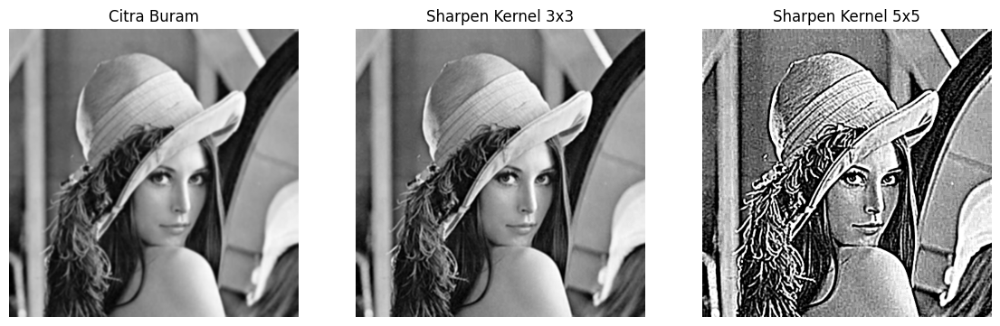

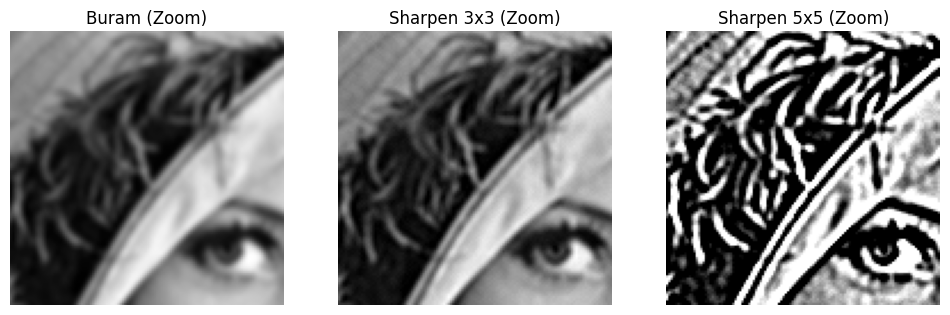

In [17]:
# Muat citra dan ubah ke grayscale
img_t2 = cv.imread(base_path + 'lena.jpg')
gray_t2 = cv.cvtColor(img_t2, cv.COLOR_BGR2GRAY)

# b. Simulasikan citra yang sedikit buram (blurry) dengan Gaussian Blur
blurry_t2 = cv.GaussianBlur(gray_t2, (5, 5), 1.5)

# a. Kernel penajaman ukuran 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]])

kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, 25, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1]])

sharpen_3x3 = cv.filter2D(blurry_t2, -1, kernel_sharpen_3x3)
sharpen_5x5 = cv.filter2D(blurry_t2, -1, kernel_sharpen_5x5)

# c. Evaluasi:
#    - Kejelasan tepi -> variance of Laplacian (makin tinggi = makin tajam)
#    - Distorsi       -> PSNR hasil penajaman terhadap citra asli (sebelum diburamkan)
def ukur_ketajaman(image):
    return cv.Laplacian(image, cv.CV_64F).var()

def hitung_psnr(citra_asli, citra_uji):
    mse = np.mean((citra_asli.astype(np.float64) - citra_uji.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 20 * math.log10(255.0 / math.sqrt(mse))

print(f"{'Citra':<15}{'Variance of Laplacian':>24}{'PSNR vs asli (dB)':>20}")
for nama, citra in [("Citra buram", blurry_t2),
                    ("Sharpen 3x3", sharpen_3x3),
                    ("Sharpen 5x5", sharpen_5x5)]:
    print(f"{nama:<15}{ukur_ketajaman(citra):>24.2f}{hitung_psnr(gray_t2, citra):>20.2f}")

show_side_by_side([blurry_t2, sharpen_3x3, sharpen_5x5],
                  ["Citra Buram", "Sharpen Kernel 3x3", "Sharpen Kernel 5x5"], figsize=(14, 5))

# Potongan citra (zoom) untuk mengamati halo/overshoot pada tepi
h, w = blurry_t2.shape
ys, ye, xs, xe = h // 3, h // 3 + 120, w // 3, w // 3 + 120
show_side_by_side([blurry_t2[ys:ye, xs:xe],
                   sharpen_3x3[ys:ye, xs:xe],
                   sharpen_5x5[ys:ye, xs:xe]],
                  ["Buram (Zoom)", "Sharpen 3x3 (Zoom)", "Sharpen 5x5 (Zoom)"], figsize=(12, 4))

**Jawaban Tugas 2 (c) — Evaluasi:**

Evaluasi dilakukan dengan dua ukuran:
- **Kejelasan tepi** diukur dengan *variance of Laplacian* (semakin tinggi, tepi semakin tajam/terlihat).
- **Distorsi** diukur dengan PSNR hasil penajaman terhadap citra asli yang tajam (semakin rendah, hasil semakin jauh dari kondisi asli → artefak semakin besar).

Berdasarkan tabel output di atas, kedua kernel sama-sama berhasil menaikkan ketajaman dibanding citra buram. Kernel **5x5** menghitung tetangga dalam rentang yang lebih luas sehingga efek penajamannya lebih kuat dan tebal, namun sisi buruknya: lebih mudah menimbulkan *halo/overshoot* di pinggir tepi, lebih rentan **mengamplifikasi noise**, dan komputasinya lebih berat. Kernel **3x3** memberikan kenaikan ketajaman yang cukup dengan **distorsi paling kecil** dan hasil yang lebih bersih.

Kesimpulan: untuk digunakan sehari-hari, **kernel penajaman 3x3 lebih optimal** karena keseimbangan terbaik antara kejelasan tepi dan distorsi/noise yang dihasilkan. Kernel 5x5 hanya lebih tepat dipakai bila citra benar-benar buram dan memang dibutuhkan penajaman yang sangat kuat.

### 3. Tugas Kreasi: Filter Kartun Sederhana

a. Buatlah sebuah fungsi kustom bernama `kartun(image)` yang menggabungkan:
   - Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
   - Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
   - Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.
b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

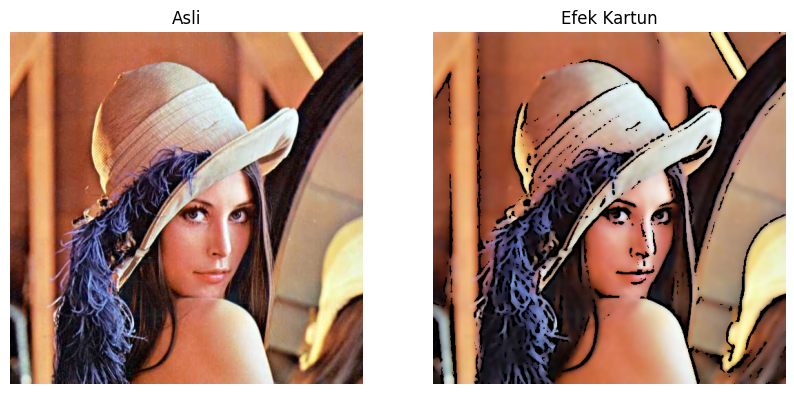

In [18]:
def kartun(image):
    """Filter kartun sederhana: bilateral filter + adaptive threshold,
    digabungkan dengan operasi logika (bitwise AND)."""
    # 1) Penghalusan warna menggunakan bilateral filter agar area warna menjadi rata
    smooth = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2) Deteksi garis tepi menggunakan adaptive threshold
    #    (median blur terlebih dahulu agar noise kecil tidak ikut terdeteksi sebagai tepi)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 5)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # 3) Gabungkan warna halus dengan garis tepi menggunakan operasi logika/perkalian piksel
    edges_bgr = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    hasil = cv.bitwise_and(smooth, edges_bgr)
    return hasil

img_t3 = cv.imread(base_path + 'lena.jpg')
hasil_kartun = kartun(img_t3)

# b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan
show_side_by_side([img_t3, hasil_kartun], ["Asli", "Efek Kartun"], figsize=(10, 5))